In [1]:
file_name="nts.mu2e.CosmicCRYSignalAllMix2BBTriggered.MDC2020aw_best_v1_3_v06_06_00.001202_00005005.root"
branches = {
    "evt": ["event", "subrun", "run"],
    "crvmc": ["crvcoincsmc.valid", "crvcoincsmc.primaryE", "crvcoincsmc.primaryPdgId", "crvcoincsmc.primary.fCoordinates.fY", "crvcoincsmc.gparent.fCoordinates.fY", "crvcoincsmc.gparentPdgId"],
    "crv" : ["crvcoincs.PEs"]
}
# true/false was an MC particle found that matches the coincidence triplets?""]

In [2]:
from pyutils.pyprocess import Processor 
processor = Processor(use_remote=True, location="disk") # file_name)

[pyutils] [INFO] Setting up...
[pyutils] [OK] Ready
[pyprocess] [INFO] Initialised Processor:
	path = 'EventNtuple/ntuple'
	use_remote = True
	location = disk
	schema = root
	verbosity=1


In [3]:
data = processor.process_data(file_name=file_name, branches=branches)

[pyprocess] [OK] Completed process on nts.mu2e.CosmicCRYSignalAllMix2BBTriggered.MDC2020aw_best_v1_3_v06_06_00.001202_00005005.root


In [4]:
import awkward as ak
data.type.show()

2557 * {
    evt: {
        event: int32,
        subrun: int32,
        run: int32
    },
    crvmc: {
        "crvcoincsmc.valid": var * bool,
        "crvcoincsmc.primaryE": var * float32,
        "crvcoincsmc.primaryPdgId": var * int32,
        "crvcoincsmc.primary.fCoordinates.fY": var * float32,
        "crvcoincsmc.gparent.fCoordinates.fY": var * float32,
        "crvcoincsmc.gparentPdgId": var * int32
    },
    crv: {
        "crvcoincs.PEs": var * float32
    }
}


In [5]:
# valid = ak.sum(data["crvmc"]["crvcoincsmc.valid"])
# total = len(data["crvmc"]["crvcoincsmc.valid"])
# non_valid = valid-total
# print(f"Number of valid coincidences: {valid}")
# print(f"Number of non-valid coincidences: {non_valid}")

In [6]:
# flat_valid = ak.flatten(data["crvmc"]["crvcoincsmc.valid"])
# n_valid = ak.sum(flat_valid)
# n_total = len(flat_valid)
# n_non_valid = n_total - n_valid
# print(f"Total coincidences: {n_total}")
# print(f"Valid (MC matched): {n_valid} ({n_valid/n_total*100:.1f}%)")
# print(f"Non-valid: {n_non_valid} ({n_non_valid/n_total*100:.1f}%)")


In [7]:
import numpy as np
flat_pdg = ak.flatten(data["crvmc"]["crvcoincsmc.primaryPdgId"])
unique, counts = np.unique(flat_pdg, return_counts=True)

for pdg, count in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"  PDG {pdg:>8d}: {count:>6d} ({count/len(flat_pdg)*100:.1f}%)")


  PDG       22:   2393 (34.4%)
  PDG     2112:   1820 (26.2%)
  PDG       13:   1388 (19.9%)
  PDG      -13:   1348 (19.4%)
  PDG     2212:      5 (0.1%)
  PDG     -211:      2 (0.0%)
  PDG      211:      1 (0.0%)
  PDG 1000100230:      1 (0.0%)
  PDG 1000130280:      1 (0.0%)


['evt', 'crvmc', 'crv']
[pyplot] [INFO] Initialised Plot with mu2e.mplstyle and verbosity = 1
[pyplot] [OK] Wrote:
	h1o_primary_y_by_type.png


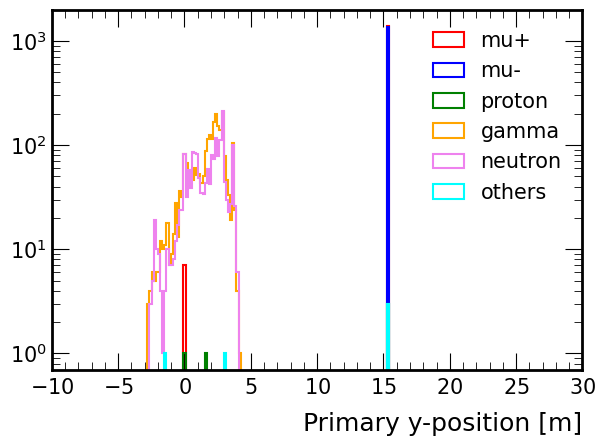

In [11]:
# Check what keys are available
print(data.fields)
flat_primary_y = ak.flatten(data["crvmc"]["crvcoincsmc.primary.fCoordinates.fY"])*1e-3
flat_pdg = ak.flatten(data["crvmc"]["crvcoincsmc.primaryPdgId"])

from pyutils.pyplot import Plot

Plot().plot_1D_overlay(
    {
        "mu+": flat_primary_y[flat_pdg == 13],
        "mu-": flat_primary_y[flat_pdg == -13],
        "proton": flat_primary_y[flat_pdg == 2212],
        "gamma": flat_primary_y[flat_pdg == 22],
        "neutron": flat_primary_y[flat_pdg == 2112],
        "others": flat_primary_y[~np.isin(flat_pdg, [13, -13, 22, 2212, 2112])],
    },
    nbins=250,
    xmin=-10,
    xmax=30,
    xlabel="Primary y-position [m]",
    # title="Primary y-position distribution by particle type",
    log_y=True,
    leg_pos="upper right",
    out_path="h1o_primary_y_by_type.png"
)




In [12]:
# flat_gparent_y = ak.flatten(data["crvmc"]["crvcoincsmc.gparent.fCoordinates.fY"])

# plotter.plot_1D_overlay(
#     {
#         "mu+": flat_gparent_y[flat_pdg == 13],
#         "mu-": flat_gparent_y[flat_pdg == -13],
#         "proton": flat_gparent_y[flat_pdg == 2212],
#         "photon": flat_gparent_y[flat_pdg == 22],
#         "neutron": flat_gparent_y[flat_pdg == 2112],
#     },
#     nbins=100,
#     xlabel="Grandparent y-position [mm]",
#     title="Grandparent y-position by primary particle type",
#     log_y=True,
# )


In [13]:
# # Grandparent PDG IDs
# flat_gparent_pdg = ak.flatten(data["crvmc"]["crvcoincsmc.gparentPdgId"])
# unique, counts = np.unique(flat_gparent_pdg, return_counts=True)
# print("Grandparent PDG IDs:")
# for pdg, count in sorted(zip(unique, counts), key=lambda x: -x[1]):
#     print(f"  PDG {pdg:>12d}: {count:>6d} ({count/len(flat_gparent_pdg)*100:.1f}%)")

# # Grandparent y-position
# flat_gparent_y = ak.flatten(data["crvmc"]["crvcoincsmc.gparent.fCoordinates.fY"])

# plotter.plot_1D_overlay(
#     {
#         "mu+": flat_gparent_y[flat_pdg == 13],
#         "mu-": flat_gparent_y[flat_pdg == -13],
#         "proton": flat_gparent_y[flat_pdg == 2212],
#         "photon": flat_gparent_y[flat_pdg == 22],
#         "neutron": flat_gparent_y[flat_pdg == 2112],
#     },
#     nbins=100,
#     xlabel="Grandparent y-position [mm]",
#     title="Grandparent y-position by primary type",
#     log_y=True,
# )


In [14]:
from pyutils.pyprint import Print
printer = Print()
printer.print_n_events(data)

[pyprint] [INFO] Initialised Print with verbose = False and precision = 1
[pyprint] [INFO] Printing 1 event(s)...

[pyprint] [INFO] -------------------------------------------------------------------------------------
[pyprint] [INFO] evt.event: 3778
[pyprint] [INFO] evt.subrun: 5005
[pyprint] [INFO] evt.run: 1202
[pyprint] [INFO] crvmc.crvcoincsmc.valid: [True, True]
[pyprint] [INFO] crvmc.crvcoincsmc.primaryE: [1.41e+04, 1.41e+04]
[pyprint] [INFO] crvmc.crvcoincsmc.primaryPdgId: [-13, -13]
[pyprint] [INFO] crvmc.crvcoincsmc.primary.fCoordinates.fY: [1.54e+04, 1.54e+04]
[pyprint] [INFO] crvmc.crvcoincsmc.gparent.fCoordinates.fY: [1.54e+04, 1.54e+04]
[pyprint] [INFO] crvmc.crvcoincsmc.gparentPdgId: [-13, -13]
[pyprint] [INFO] crv.crvcoincs.PEs: [849, 1.26e+03]
[pyprint] [INFO] -------------------------------------------------------------------------------------
[pyprint] [INFO] 


In [15]:
# n_coincs = ak.num(data["crv"]["crvcoincs.PEs"])
# n_mc = ak.num(data["crvmc"]["crvcoincsmc.valid"])
# n_valid = ak.sum(data["crvmc"]["crvcoincsmc.valid"], axis=1)

# print(f"Events with more coincs than MC: {ak.sum(n_coincs > n_mc)}")
# print(f"Events with more coincs than valid MC: {ak.sum(n_coincs > n_valid)}")
# print(f"Mean coincs per event: {ak.mean(n_coincs):.2f}")
# print(f"Mean valid MC per event: {ak.mean(n_valid):.2f}")


In [16]:
flat_primary_y = ak.flatten(data["crvmc"]["crvcoincsmc.primary.fCoordinates.fY"])
flat_pdg = ak.flatten(data["crvmc"]["crvcoincsmc.primaryPdgId"])

# Cosmic muons should originate from high y
# What's the y distribution?
print(f"Min primary y: {np.min(flat_primary_y):.0f}")
print(f"Max primary y: {np.max(flat_primary_y):.0f}")
print(f"Median primary y: {np.median(flat_primary_y):.0f}")

# Try a cut — cosmics from above, pileup from near detector
y_cut = 5000  # adjust based on distribution
n_cosmic = ak.sum(flat_primary_y > y_cut)
n_pileup = ak.sum(flat_primary_y <= y_cut)
print(f"\nAbove y={y_cut}: {n_cosmic} ({n_cosmic/len(flat_primary_y)*100:.1f}%) -> likely cosmic")
print(f"Below y={y_cut}: {n_pileup} ({n_pileup/len(flat_primary_y)*100:.1f}%) -> likely pileup")


Min primary y: -2779
Max primary y: 15365
Median primary y: 2870

Above y=5000: 2735 (39.3%) -> likely cosmic
Below y=5000: 4224 (60.7%) -> likely pileup


In [17]:
# CRY cosmic plane is at y ~ 15365 (your max)
# Check: are all muons from the cosmic plane?
muon_mask = np.abs(flat_pdg) == 13
muon_y = flat_primary_y[muon_mask]
print(f"Muon primary y: min={np.min(muon_y):.0f}, max={np.max(muon_y):.0f}, median={np.median(muon_y):.0f}")

photon_y = flat_primary_y[flat_pdg == 22]
print(f"Photon primary y: min={np.min(photon_y):.0f}, max={np.max(photon_y):.0f}, median={np.median(photon_y):.0f}")

neutron_y = flat_primary_y[flat_pdg == 2112]
print(f"Neutron primary y: min={np.min(neutron_y):.0f}, max={np.max(neutron_y):.0f}, median={np.median(neutron_y):.0f}")


Muon primary y: min=-30, max=15365, median=15365
Photon primary y: min=-2779, max=4172, median=2120
Neutron primary y: min=-2496, max=4077, median=2064


In [18]:
# is_cosmic = (flat_primary_y > 10000)  # CRY plane at ~15365
# n_cosmic = ak.sum(is_cosmic)
# n_pileup = ak.sum(~is_cosmic)
# print(f"Cosmic: {n_cosmic} ({n_cosmic/len(flat_primary_y)*100:.1f}%)")
# print(f"Pileup: {n_pileup} ({n_pileup/len(flat_primary_y)*100:.1f}%)")


In [19]:
# flat_primaryE = ak.flatten(data["crvmc"]["crvcoincsmc.primaryE"])

# plotter.plot_1D_overlay(
#     {
#         "mu": flat_primaryE[np.abs(flat_pdg) == 13],
#         "photon": flat_primaryE[flat_pdg == 22],
#         "neutron": flat_primaryE[flat_pdg == 2112],
#     },
#     nbins=100,
#     xmin=0,
#     xmax=1e5,
#     xlabel="Primary energy [MeV]",
#     log_y=True,
#     log_x=True,
# )
